In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv(r"G:\My Drive\BrainStation\BrainStationCapstone\Scripts and Notebooks\Raw Data\2023-03-03 Export\2023-03-02 Cleaning DataSet V2.2 out.csv", low_memory = True)

In [3]:
df.head()

,Unnamed: 0,Cites,Authors,Title,Year,Source,CitesURL,GSRank,QueryDate,Type,CitationURL,ECC,CitesPerYear,CitesPerAuthor,AuthorCount,query_id
0,0,4186,"D Shi, V Adinolfi, R Comin, M Yuan, E Alarousu...",Low trap-state density and long carrier diffus...,2015.0,Science,https://scholar.google.com/scholar?oi=bibs&hl=...,1,2023-03-02 08:59:01,Journal article,https://scholar.google.com/citations?view_op=v...,4186,523.25,523,8,0.0
1,1,2319,"K Lin, J Xing, LN Quan, FPG de Arquer, X Gong,...",Perovskite light-emitting diodes with external...,2018.0,Nature,https://scholar.google.com/scholar?oi=bibs&hl=...,2,2023-03-02 08:59:01,Journal article,https://scholar.google.com/citations?view_op=v...,2319,463.80,258,9,0.0
2,2,2163,"SA McDonald, G Konstantatos, S Zhang, PW Cyr, ...",Solution-processed PbS quantum dot infrared ph...,2005.0,Nature materials,https://scholar.google.com/scholar?oi=bibs&hl=...,3,2023-03-02 08:59:01,Journal article,https://scholar.google.com/citations?view_op=v...,2163,120.17,309,7,0.0
3,3,1951,"H Tan, A Jain, O Voznyy, X Lan, FP García de A...",Efficient and stable solution-processed planar...,2017.0,Science,https://scholar.google.com/scholar?oi=bibs&hl=...,4,2023-03-02 08:59:01,Journal article,https://scholar.google.com/citations?view_op=v...,1951,325.17,279,7,0.0
4,4,1897,"G Konstantatos, I Howard, A Fischer, S Hooglan...",Ultrasensitive solution-cast quantum dot photo...,2006.0,Nature,https://scholar.google.com/scholar?oi=bibs&hl=...,5,2023-03-02 08:59:01,Journal article,https://scholar.google.com/citations?view_op=v...,1897,111.59,271,7,0.0


In [4]:
df['Authors'].value_counts().count() == df['Title'].value_counts().count()

False

In [5]:
num = df['Title'].value_counts().count() - df['Authors'].value_counts().count()
print(f'There are {num} more unique titles than author lists')

There are 1496 more unique titles than author lists


This implies there are some unique titles that share the same author list. Let's find them.

First, for simplicity let's convert all the `Titles` into ASCII encoding and only capitalize the first letter.

In [6]:
def encode_str(row):
    return row['Title'].encode('ascii', 'ignore').decode('ascii').strip().lower()

df1 = df.assign(Title = df.apply(encode_str, axis = 1))

In [7]:
df1['Authors'].value_counts().count() == df1['Title'].value_counts().count()

False

In [8]:
num = df1['Title'].value_counts().count() - df1['Authors'].value_counts().count()
print(f'There are {num} more unique titles than author lists')

There are 1330 more unique titles than author lists


That helped a little, but let's do some more searching.

In [9]:
def print_title(row):
    au = row['Title']
    if au.count() > 1 & au.unique().shape[0] != 1:
        print(row['Title'])
    
df1.groupby('Authors').apply(print_title)

6896              perovskite solar cells go lead free
7033    specialty grand challenges in optoelectronics
Name: Title, dtype: object
4645    interface broadening due to ion mixing during ...
4664    dynamics of ion bombardment-induced modificati...
Name: Title, dtype: object
4567    study of tio2 film growth mechanisms in low-pr...
4659    ion-surface interactions on  at the radiofrequ...
Name: Title, dtype: object
17484    prediction of two-dimensional bismuth-based ch...
17487    ab-initio-driven prediction of puckered penta-...
17527    prediction of two-dimensional bismuth-based ch...
17530    ab-initio-driven prediction of puckered penta-...
Name: Title, dtype: object
17480    biphenylene monolayer as a two-dimensional non...
17492    novel two-dimensional alsb and insb monolayers...
17523    biphenylene monolayer as a two-dimensional non...
17535    novel two-dimensional alsb and insb monolayers...
Name: Title, dtype: object
17481    two-dimensional porous graphitic carbon nitr

16530    iso-propylthiobiuret-copper and indium complex...
16536    high-throughput route to cu2 xs nanoparticles ...
Name: Title, dtype: object
2633    enhancing the radiative decay rate of fluoresc...
2648    a design for an optical-nanocavity optimized f...
Name: Title, dtype: object
1459    infrared transition moment orientational analy...
1492    spatial orientation and order of structure-def...
Name: Title, dtype: object
3239    long-range electronic reconstruction to a dxz,...
3260    emergent vortices at a ferromagnetic supercond...
Name: Title, dtype: object
15545    commercializing colloidal quantum dot photovol...
15553       artificial intelligence-enabled science poetry
15558    dirac material heterostructures lead to next-g...
15561    theoretical framework for charge transport in ...
15562    bio focus: complex microstructures emerge from...
15563    polymers embedded with mechanophores emit whit...
15564    truncated tetrahedral quantum dots self-assemb...
15565    dend

11694    efficient visiblelight driven photothermal con...
11745    photothermal catalysis: efficient visiblelight...
Name: Title, dtype: object
8704    3% fe2o3: cr2o3- an excellent magneto-opto-ele...
8722    iron-doped titania for magneto-opto-electronic...
Name: Title, dtype: object
9619    temperature dependence of the photoluminescenc...
9734    surface physics, nanoscale physics, low-dimens...
Name: Title, dtype: object
22273    suppression of degradation induced by negative...
22283    drain bias effect on the instability of amorph...
Name: Title, dtype: object
16415    -ray irradiation effect on hysteresis symmetry...
16433    voltage shift of hysteresis loops of srbi2ta2o...
16470    -ray irradiation effect on hysteresis symmetry...
16488    voltage shift of hysteresis loops of srbi2ta2o...
Name: Title, dtype: object
4062    facile deposition of high-quality cs2agbibr6 f...
4252                                           cs2agbibr6
Name: Title, dtype: object
5451    control of

15817    multiwavelength ganbased surfaceemitting laser...
15838    surfaceemitting lasers: multiwavelength ganbas...
15881    multiwavelength ganbased surfaceemitting laser...
15902    surfaceemitting lasers: multiwavelength ganbas...
Name: Title, dtype: object
4057    two-and three-photon absorption of semiconduct...
4073    high efficiency and nearly cubic power depende...
Name: Title, dtype: object
20930    synthesis of a novel unsymmetrical zn (ii) pht...
20956    synthesis of a novel unsymmetrical zn (ii) pht...
Name: Title, dtype: object
20937    [1] benzothieno [3, 2b][1] benzothiophenephtha...
20954    cover feature:[1] benzothieno [3, 2b][1] benzo...
Name: Title, dtype: object
20938    metalorganic green dye: chemical and physical ...
20955    reply to the comment on metalorganic green dye...
Name: Title, dtype: object
8746    long phase coherence time and number squeezing...
8848    general physics: statistical and quantum mecha...
Name: Title, dtype: object
13382    some ne

15121    utjecaj obrade erozimatom na mikrostrukturu po...
15133    effects of wire edm on the microstructure of p...
15185    utjecaj obrade erozimatom na mikrostrukturu po...
15197    effects of wire edm on the microstructure of p...
Name: Title, dtype: object
5579                             phys. status solidi appl
5640    memristive devices based on solutionprocessed ...
Name: Title, dtype: object
112      2d matrix engineering for homogeneous quantum ...
4476     2d matrix engineering for homogeneous quantum ...
7093     2d matrix engineering for homogeneous quantum ...
15512    2d matrix engineering for homogeneous quantum ...
16552    2d matrix engineering for homogeneous quantum ...
19980    2d matrix engineering for homogeneous quantum ...
20005                        k, a. amassian and eh sargent
Name: Title, dtype: object
12422    nonlinear microscopy of strain in lead iodide ...
12433       nonlinear microscopy of lead iodide nanosheets
Name: Title, dtype: object
11282    

...

17504    structural dependent, dielectric and conductio...
17508    interfacial strain and shell thickness effect ...
17547    structural dependent, dielectric and conductio...
17551    interfacial strain and shell thickness effect ...
Name: Title, dtype: object
763     organic electronic devices and their functiona...
781     energy levels at interfaces between metals and...
847     electronic structure of interfaces with conjug...
1074    opportunities for energy level tuning at inorg...
1162    frontiers of controlling energy levels at inte...
1170    johannes frisch, martin herder, philipp herrma...
1171    cover picture: electronic structure of interfa...
1173    charge transfer and polarization at interfaces...
Name: Title, dtype: object
913     lack of thermodynamic equilibrium in conjugate...
1132    semiconductors ii: surfaces, interfaces, micro...
Name: Title, dtype: object
1072    photoemission spectroscopic investigation on t...
1189    structural, mechanical, thermodynamic

6667    ambipolar organic field-effect transistors fab...
6700    photovoltaic effects on the organic ambipolar ...
Name: Title, dtype: object
20567    poly (ethylene glycol)[60] fullerenebased mate...
20572    cover feature: poly (ethylene glycol)[60] full...
Name: Title, dtype: object
10708    theoretical study of crossed and parallel carb...
10778    surface physics, low-dimensional systems, and ...
Name: Title, dtype: object
947    influence of alkyl chain substitution on sexit...
970    spontaneous charge transfer at organic-organic...
Name: Title, dtype: object
955     vacuum sublimed , -dihexylsexithiophene thin f...
1180    033717 vacuum sublimed,-dihexylsexithiophene t...
Name: Title, dtype: object
8214    electrical characterization of the threshold f...
8220    effect of ion mass on the evolution of extende...
Name: Title, dtype: object
19336    tailored local bandgap modulation as a strateg...
19341    tailored local bandgap modulation as a strateg...
Name: Title, dtype: ob

154      photovoltage field-effect transistors
732                    corrections &amendments
19962    photovoltage field-effect transistors
19976                  corrections &amendments
Name: Title, dtype: object
7282    charge transfer induced excited state twisting...
7431    kinetics; atmospheric and environmental physic...
Name: Title, dtype: object
1999    monoclinic phase in reactor powders of ultra-h...
2126    structure and properties-monoclinic phase in r...
Name: Title, dtype: object
18329    investigations of environmental induced effect...
18330    study of optical properties and light induced ...
18352    investigations of environmental induced effect...
18353    study of optical properties and light induced ...
Name: Title, dtype: object
2415    cavity polaritons in microcavities containing ...
2587    microcavity polaritons in materials with weak ...
Name: Title, dtype: object
3869    synergistic interaction of dyes and semiconduc...
3974    photovoltaics: synergistic 

18619    carbazolecontaining polymerassisted trap passi...
18623    carbazolecontaining polymerassisted trap passi...
Name: Title, dtype: object
18595    high colorrendering index and stable white lig...
18620    white lightemitting diodes: high colorrenderin...
Name: Title, dtype: object
24032    enhanced nanoscale piezoresponse and ferroelec...
24033    nano-confinement driven modulation of molecula...
Name: Title, dtype: object
51                       quantum-dot-in-perovskite solids
7071                     quantum-dot-in-perovskite solids
7259    colloidal quantum dot surface engineering for ...
Name: Title, dtype: object
5385    exploring agbixi3x+ 1 semiconductor thin films...
5401    agbi2i7 layers with controlled surface morphol...
Name: Title, dtype: object
4248    special issue on the 40th anniversary of unive...
4249    special issue on the 40th anniversary of unive...
Name: Title, dtype: object
5103    allcopper nanocluster based downconversion whi...
5293    lightemittin

""


Let's look at some of the author papers more closely

In [10]:
author1 = df1.loc[6896, 'Authors']
author2 = df1.loc[7033, 'Authors']
print(author1, author2)
print('Are these authors the same?', df1.loc[6896, 'Authors'] == df1.loc[7033, 'Authors'])

A Abate A Abate
Are these authors the same? True


It looks like some of the redundancy come from papers with only one author. Let's try to find those

In [11]:
df1[df1['AuthorCount'] == 1].head()

,Unnamed: 0,Cites,Authors,Title,Year,Source,CitesURL,GSRank,QueryDate,Type,CitationURL,ECC,CitesPerYear,CitesPerAuthor,AuthorCount,query_id
26,26,739,EH Sargent,colloidal quantum dot solar cells,2012.0,Nature photonics,https://scholar.google.com/scholar?oi=bibs&hl=...,27,2023-03-02 08:59:01,Journal article,https://scholar.google.com/citations?view_op=v...,739,67.18,739,1,0.0
59,60,415,EH Sargent,infrared photovoltaics made by solution proces...,2009.0,Nature photonics,https://scholar.google.com/scholar?oi=bibs&hl=...,61,2023-03-02 08:59:01,Journal article,https://scholar.google.com/citations?view_op=v...,415,29.64,415,1,0.0
147,148,205,EH Sargent,"solar cells, photodetectors, and optical sourc...",2008.0,Advanced materials,https://scholar.google.com/scholar?oi=bibs&hl=...,149,2023-03-02 08:59:01,Journal article,https://scholar.google.com/citations?view_op=v...,205,13.67,205,1,0.0
485,526,31,EH Sargent,solution-processed infrared optoelectronics: p...,2008.0,Ieee journal of selected topics in quantum ele...,https://scholar.google.com/scholar?oi=bibs&hl=...,527,2023-03-02 08:59:01,Journal article,https://scholar.google.com/citations?view_op=v...,31,2.07,31,1,0.0
515,558,26,E Sargent,a sensitive pair,2012.0,Nature nanotechnology,https://scholar.google.com/scholar?oi=bibs&hl=...,559,2023-03-02 08:59:01,Journal article,https://scholar.google.com/citations?view_op=v...,26,2.36,26,1,0.0


In [12]:
df1_1 = df1[df1['AuthorCount'] != 1]

In [13]:
num = df1_1['Title'].value_counts().count() - df1_1['Authors'].value_counts().count()
print(f'There are {num} more unique titles than author lists')

There are 1200 more unique titles than author lists


Excluding the papers with only one author helped more, but we still have more unique titles than authors. Let's further investigate.

In [14]:
def print_title(row):
    au = row['Title']
    if au.count() > 1 & au.unique().shape[0] != 1:
        print(row['Title'])
    
df1_1.groupby('Authors').apply(print_title)

4645    interface broadening due to ion mixing during ...
4664    dynamics of ion bombardment-induced modificati...
Name: Title, dtype: object
4567    study of tio2 film growth mechanisms in low-pr...
4659    ion-surface interactions on  at the radiofrequ...
Name: Title, dtype: object
17484    prediction of two-dimensional bismuth-based ch...
17487    ab-initio-driven prediction of puckered penta-...
17527    prediction of two-dimensional bismuth-based ch...
17530    ab-initio-driven prediction of puckered penta-...
Name: Title, dtype: object
17480    biphenylene monolayer as a two-dimensional non...
17492    novel two-dimensional alsb and insb monolayers...
17523    biphenylene monolayer as a two-dimensional non...
17535    novel two-dimensional alsb and insb monolayers...
Name: Title, dtype: object
17481    two-dimensional porous graphitic carbon nitrid...
17512    erratum: two-dimensional porous graphitic carb...
17524    two-dimensional porous graphitic carbon nitrid...
17555    er

7657    charge transfer through molecules with multipl...
7672    single molecule charge transport: from a quant...
Name: Title, dtype: object
11477    doping studies of the magnetic cobaltocuprate ...
11510    doping studies of the magnetic cobaltocuprate ...
11559    doping studies of the magnetic cobaltocuprate ...
11592    doping studies of the magnetic cobaltocuprate ...
Name: Title, dtype: object
11441    negative lattice expansion from the supercondu...
11471    correction: negative lattice expansion from th...
11523    negative lattice expansion from the supercondu...
11553    correction: negative lattice expansion from th...
Name: Title, dtype: object
11472    structure and magnetism of the layered rutheno...
11475    the synthesis, structure and magnetic properti...
11554    structure and magnetism of the layered rutheno...
11557    the synthesis, structure and magnetic properti...
Name: Title, dtype: object
11493    a sr study of the magnetoresistive ruthenocupr...
11504    

2647    preparation and photovoltaic properties of pyr...
2663    pyrene-benzo [1, 2, 5] thiadiazole based conju...
Name: Title, dtype: object
18630    the use of siloxanes, silsesquioxanes, and sil...
18643    modified boron subphthalocyanines with stable ...
Name: Title, dtype: object
24064    the application of fto-cu2o/ag3po4 heterojunct...
24067    sulphate radical enhanced photoelectrochemical...
Name: Title, dtype: object
14145    electrodeposited re-promoted ni foams as a cat...
14149    microstructure and composition of pulse plated...
Name: Title, dtype: object
19324                photo-rechargeable zinc-ion batteries
19342    manganese oxide-based heterogeneous electrocat...
24145                photo-rechargeable zinc-ion batteries
24150    manganese oxide-based heterogeneous electrocat...
Name: Title, dtype: object
11927    charge separation and (triplet) recombination ...
11956    charge separation and recombination in small b...
Name: Title, dtype: object
2371     visua

3539     luminescence from plasma deposited silicon films
3541    visible luminescence from nanocrystalline sili...
Name: Title, dtype: object
18674    assembly of quantum dots on peptide nanostruct...
18682    thin film mesoscale organization of nanopartic...
18704    assembly of quantum dots on peptide nanostruct...
18712    thin film mesoscale organization of nanopartic...
Name: Title, dtype: object
23198    surface oxidation mechanism of a refractory hi...
23202    understanding the extremely poor lattice therm...
23208    effect of oxidation on the thermal expansion o...
23212    understanding the anisotropic phonon thermal t...
Name: Title, dtype: object
23210    structure and energetics of zrc (100)|| c-zro2...
23211    characterizing the zrc(111)/c-zro2(111) hetero...
Name: Title, dtype: object
21095    effect of particle size on the optical propert...
21100    kramerskronig method for determination of opti...
Name: Title, dtype: object
23338    dna-mediated three-dimensional a

3391    molecular beam growth of micrometer-size graph...
3440           molecular beam epitaxy of graphene on mica
Name: Title, dtype: object
989     in-situ tuning threshold voltage of field-effe...
1452    in-situ tuning threshold voltage of field-effe...
Name: Title, dtype: object
9640    picosecond photoluminescence decay time in col...
9658    the role of intrinsic and surface states on th...
Name: Title, dtype: object
5872     preisach modeling of ferroelectric pinched loops
5885    preisach distribution function approach to pie...
5911    piezoelectric hysteresis analysis and loss sep...
5950    temperature dependence of piezoelectric proper...
Name: Title, dtype: object
18272    hemin-modified sno2/metglas electrodes for the...
18283    hemin-modified simultaneous electrochemical sn...
18304    hemin-modified sno2/metglas electrodes for the...
18315    hemin-modified simultaneous electrochemical sn...
Name: Title, dtype: object
7277    optical nonlinearities of glass doped wit

...

23845    enhanced photoelectrochemical solar cells base...
23847    highly efficient natural dye-sensitized photoe...
Name: Title, dtype: object
9650    real-time investigation of solvent swelling in...
9730    inhomogeneous, disordered, and partially order...
Name: Title, dtype: object
2652    perovskites on ice: an additivefree approach t...
2681    front cover: perovskites on ice: an additivefr...
Name: Title, dtype: object
8028    powder injection moulding of premixed ferritic...
8109    powder extrusion moulding of 430l stainless st...
Name: Title, dtype: object
9327    structure, microstructure, and high-temperatur...
9373    structure, microstructure, and high-temperatur...
Name: Title, dtype: object
13040    efficiency limit of perovskite/si tandem solar...
13050    modeling the performance limitations and prosp...
19052    efficiency limit of perovskite/si tandem solar...
19055    modeling the performance limitations and prosp...
19082    efficiency limit of perovskite/si tand

23471    tailoring tripleanion perovskite material for ...
23482    indoor perovskite cells: tailoring tripleanion...
Name: Title, dtype: object
156     structural, optical, and electronic studies of...
7107    structural, optical, and electronic studies of...
7261    structural, optical, and electronic studies of...
Name: Title, dtype: object
1684    design and use of a batch reactor for catalyti...
1778    catalytic decomposition of different monoprope...
Name: Title, dtype: object
22031    silicon nanowire heterostructures for advanced...
22041    efficient visible light photocatalysis and tun...
22044    effect of rapid thermal annealing on the photo...
22045    silicon nanowire heterostructures: growth stra...
Name: Title, dtype: object
22030    origin of visible and near-infrared photolumin...
22037    photoluminescence signature of resonant energy...
Name: Title, dtype: object
5958    local hard and soft pinning of 180 domain wall...
5970    individual barkhausen pulses of ferro

3552    maintaining reproducible plasma reactor wall c...
3637    formation and removal of composite halogenated...
Name: Title, dtype: object
8737    rd 2624-a new barley (hordeum vulgare l.) vari...
8738    rd 2592-a new high yielding barley (hordeum vu...
Name: Title, dtype: object
3540    study of surface reactions during plasma enhan...
3549    reasons for lower dielectric constant of fluor...
3563    structure and chemical composition of fluorina...
3596    detection of combinative infrared absorption b...
3635    plasma and surface diagnostics during plasma-e...
3661    silanol concentration depth profiling during p...
Name: Title, dtype: object
12747    carbon nanotube/polymer composites as a highly...
12778    enhanced hole extraction in perovskite solar c...
Name: Title, dtype: object
8640    response of palmarosa to nitrogen, phosphorus,...
8690    effect of npk and micronutrients on herb, oil ...
Name: Title, dtype: object
3123    evolution of magnetic bubble domains in man

10446    simultaneous power conversion efficiency and s...
10558    multifunctional dye interlayers: simultaneous ...
Name: Title, dtype: object
14995    a biocompatible design of kappa-carrageenan/fu...
14997    integration of ironmanganese layered double hy...
15056    a biocompatible design of kappa-carrageenan/fu...
15058    integration of ironmanganese layered double hy...
Name: Title, dtype: object
7501    hybrid graphenegiant nanocrystal quantum dot a...
7550    plasmonics: hybrid graphenegiant nanocrystal q...
Name: Title, dtype: object
12508    dna directed selfassembly of fluorescent collo...
12527    cover picture: dna directed selfassembly of fl...
Name: Title, dtype: object
9028     perovskite solar cells: understanding the role...
16722    understanding the role of cesium and rubidium ...
16756    perovskite solar cells: understanding the role...
Name: Title, dtype: object
18605    ultrastable leadfree double perovskite photode...
18617    photodetectors: ultrastable lead

""


In [15]:
df_ = df1_1
author1 = df_.loc[4645, 'Authors']
author2 = df_.loc[4664, 'Authors']
print(author1, df_.loc[4645, 'AuthorCount'])
print(author2, df_.loc[4664, 'AuthorCount'])
print('Are these authors the same?', author1 == author2)

A Amassian, M Svec, P Desjardins, L Martinu 4
A Amassian, M Svec, P Desjardins, L Martinu 4
Are these authors the same? True


It could be possible that some of these papers have identical author lists, especially since the data set only contains the first 6-7 authors. Let's try matching the titles with other variables to check.

In [16]:
def print_title(row):
    au = row['Source']
    if au.count() > 1 & au.unique().shape[0] != 1:
        print(row['Source'].values, row['Cites'].values)
    
df1_1.groupby('Title').apply(print_title)

['Chinese optics' '蚌埠学院学报'] [0 0]
['American journal of physics' 'Am. j. phys'] [19  0]
['J. phys. chem. lett' 'The journal of physical chemistry letters'] [2491 2491]
['International journal of research in engineering and bioscience'
 'International journal research in engineering and bioscience'] [3 0]
['Ieee photonics technology letters' 'Photonics technology letters'
 'Photonics technology letters'] [10 10 10]
['Journal of the american chemical society' 'Synthetic metals'] [111  31]
['The journal of physical chemistry letters' 'J. phys. chem. lett.'] [35 35]
['Journal of the american chemical society' 'J. am. chem. soc'
 'J. am. chem. soc'] [251 251 251]
['Applied physics letters' 'Appl. phys. lett.'] [47  0]
['Chemical communications' 'Royal society of chemistry'] [1 0]
['Materials science and engineering b'
 'Materials science and engineering: b'] [0 0]
['The light house journal of natural sciences'
 'The lighthouse journal of natural sciences'] [0 0]
['Journal of physics: conden

""


Some of the titles look to be grouped with different formats of the `Source` element. Let's fix that first. This could be because the article got reposted somewhere (Reposted in a blog post, for example) so let's remove the duplicates with the lowest number of citations.

In [17]:
def print_title(row):
    au = row['Source']
    if au.count() > 1 & au.unique().shape[0] != 1:
        return row[['Title', 'Cites']]
    
test_ser = df1_1.groupby('Title').apply(print_title)

In [18]:
indx_arr = []
def print_title(row):
    au = row['Source']
    if au.count() > 1 & au.unique().shape[0] != 1:
        if np.max(row['Cites']) != np.min(row['Cites']):
            idx = np.where(row['Cites'] == np.min(row['Cites']))
            indx_arr.append(row['Cites'].index[idx][0])
    
test_ser = df1_1.groupby('Title').apply(print_title)
indx_arr = np.asarray(indx_arr)
df1_2 = df1_1.drop(indx_arr, axis = 0)

In [19]:
num = df1_2['Title'].value_counts().count() - df1_2['Authors'].value_counts().count()
print(f'There are {num} more unique titles than author lists')

There are 1214 more unique titles than author lists


It looks like this actually increased the difference between the unique titles and authors. This might be from the absolute number of unique authors going down.

In [20]:
print("Are the number of unique authors the same? ", df1_1['Authors'].value_counts().count() == df1_2['Authors'].value_counts().count())

Are the number of unique authors the same?  False


In [21]:
print("Are the number of unique Titles the same? ", df1_1['Title'].value_counts().count() == df1_2['Title'].value_counts().count()) 

Are the number of unique Titles the same?  True


We've removed the rows with the low citations, let's address the variations in the journal format now.

In [22]:
def print_title(row):
    au = row['Source']
    if au.count() > 1 & au.unique().shape[0] != 1:
        print(row[['Source', 'Cites']])
        #print(row['Source'].values, row['Cites'].values)
    
test_ser = df1_2.groupby('Title').apply(print_title)

               Source  Cites
5282   Chinese optics      0
13181          蚌埠学院学报      0
                                          Source  Cites
6867                         J. phys. chem. lett   2491
12739  The journal of physical chemistry letters   2491
                                  Source  Cites
2860   Ieee photonics technology letters     10
10828       Photonics technology letters     10
10895       Photonics technology letters     10
                                          Source  Cites
10280  The journal of physical chemistry letters     35
11701                       J. phys. chem. lett.     35
                                         Source  Cites
9026   Journal of the american chemical society    251
20351                          J. am. chem. soc    251
20381                          J. am. chem. soc    251
                                     Source  Cites
18223   Materials science and engineering b      0
21054  Materials science and engineering: b      0
            

In [23]:
df1_2['Source'].value_counts()

The journal of physical chemistry c                                 799
Advanced materials                                                  723
Applied physics letters                                             667
Acs energy letters                                                  575
Acs applied materials &interfaces                                   558
                                                                   ... 
Afyon kocatepe üniversitesi fen ve mühendislik bilimleri dergisi      1
Ultrafast phenomena and nanophotonics xvi                             1
Mater res soc symp proc                                               1
The journal of supercomputing                                         1
Journal of the indian botanical society                               1
Name: Source, Length: 2060, dtype: int64

In [24]:
import re

def edit_title(row):
    title = row
    
    # Get rid of 'The'
    title = re.sub(r'^The\s', '', title)
    
    # Get rid of colons
    title = re.sub(r':', '', title)
    
    
    return title.lower()
    
df1_3 = df1_2.assign(Source = df1_2['Source'].apply(edit_title))

In [25]:
df1_3['Source'].value_counts()

journal of physical chemistry c             802
advanced materials                          723
applied physics letters                     667
acs energy letters                          575
acs applied materials &interfaces           558
                                           ... 
phys. stat. sol.(b)                           1
pis' ma v zhurnal tekhnicheskoj fiziki        1
smart sensors                                 1
thermosense xxv                               1
journal of the indian botanical society       1
Name: Source, Length: 2050, dtype: int64

In [26]:
def print_title(row):
    au = row['Source']
    if au.count() > 1 & au.unique().shape[0] != 1:
        print(row[['Source', 'Cites']])
        #print(row['Source'].values, row['Cites'].values)
    
test_ser = df1_3.groupby('Title').apply(print_title)

               Source  Cites
5282   chinese optics      0
13181          蚌埠学院学报      0
                                      Source  Cites
6867                     j. phys. chem. lett   2491
12739  journal of physical chemistry letters   2491
                                  Source  Cites
2860   ieee photonics technology letters     10
10828       photonics technology letters     10
10895       photonics technology letters     10
                                      Source  Cites
10280  journal of physical chemistry letters     35
11701                   j. phys. chem. lett.     35
                                         Source  Cites
9026   journal of the american chemical society    251
20351                          j. am. chem. soc    251
20381                          j. am. chem. soc    251
                                        Source  Cites
18224  light house journal of natural sciences      0
21056   lighthouse journal of natural sciences      0
                           

This helped matched ~10 journals, but there are still issues with mis-matched formatting of the journal names.

In [27]:
def find_abb(row):
    string = row['Source']
    match = re.match(r'^.\.', string)
    if match:
        return string
    
ser = df1_3.apply(find_abb, axis = 1)
ser.value_counts()

j. mater. chem              10
j. am. chem. soc             4
j. phys. chem. lett          3
j. indian chem. soc.         2
j. phys. condens. matter     2
j. korean phys. soc.         2
j. appl. phys.               2
j. indian chem. soc          2
j. phys.theor. chem.         2
j. phys. chem. c             2
j. mater. chem. a            2
j. chem. phys                2
j. phys; condens. matter     1
j. phys. chem                1
j. phys. chem. lett.         1
j. energy chem               1
j. magn. magn. mater         1
j. appl. phys                1
g. ye (woodhead              1
j. hydraul. eng              1
b. song                      1
j. pharm pharm scien         1
dtype: int64

In [28]:
replace_dict = {
    '蚌埠学院学报': 'chinese optics',
    'j. phys. chem. lett.':'journal of physical chemistry letters',
    'j. phys. chem. lett':'journal of physical chemistry letters',
    'j. phys. condens. matter':'journal of physics condensed matter',
    'j. phys; condens. matter':'journal of physics condensed matter',
    'j. am. chem. soc': 'journal of the american chemical society',
    'chem. commun.': 'chemical communications',
    'chem. mater.': 'chemistry of materials',
    'angewandte chemie': 'angewandte chemie international edition',
    'photonics technology letters': 'ieee photonics technology letters',
    'lighthouse journal of natural sciences': 'light house journal of natural sciences',
    'electronics': 'journal of engineering sciences',
    'cell reports physical sciences':'cell reports physical science',
    'j. mater. chem': 'journal of materials chemistry',
    'j. indian chem. soc.': 'journal of the indian chemical society',
    'j. indian chem. soc': 'journal of the indian chemical society',
    'j. korean phys. soc.': 'journal of the korean physical society',
    'j. appl. phys.': 'journal of applied physics',
    'j. appl. phys': 'journal of applied physics',
    'j. phys.theor. chem.': 'journal of physical and theoretical chemistry',
    'j. phys. chem. c': 'journal of physical chemistry c',
    'j. mater. chem. a': 'journal of physical chemistry a',
    'j. chem. phys': 'journal of chemical physics',
    'j. phys. chem': 'journal of physical chemistry',
    'j. energy chem': 'journal of energy chemistry',
    'j. magn. magn. mater': 'journal of magnetism and magnetic materials',
    'j. hydraul. eng': 'journal of hydraulic engineering',
    'j. pharm pharm scien': 'journal of pharmacy & pharmaceutical sciences'
}

In [29]:
df1_4 = df1_3.replace(replace_dict)

In [30]:
df1_4['Source'].value_counts()

journal of physical chemistry c                                      804
advanced materials                                                   723
applied physics letters                                              667
acs energy letters                                                   575
acs applied materials &interfaces                                    558
                                                                    ... 
福州大学学报 自然科学版                                                           1
handbook of organic-inorganic hibrid materials and nanocomposites      1
j fuzhou univ (nat sci)                                                1
journal of the less-common metals                                      1
journal of the indian botanical society                                1
Name: Source, Length: 2024, dtype: int64

In [31]:
def find_abb(row):
    string = row['Source']
    match = re.match(r'^.\.', string)
    if match:
        return string
    
ser = df1_4.apply(find_abb, axis = 1)
ser.value_counts()

g. ye (woodhead    1
b. song            1
dtype: int64

In [32]:
df1_4 = df1_4.drop(df1_4[df1_4['Source'] == 'b. song'].index)
df1_4 = df1_4.drop(df1_4[df1_4['Source'] == 'g. ye (woodhead'].index)

In [33]:
def find_abb(row):
    string = row['Source']
    match = re.match(r'^.\.', string)
    if match:
        return string
    
ser = df1_4.apply(find_abb, axis = 1)
ser.value_counts()

Series([], dtype: int64)

In [34]:
df1_4['Source'].value_counts()

journal of physical chemistry c                     804
advanced materials                                  723
applied physics letters                             667
acs energy letters                                  575
acs applied materials &interfaces                   558
                                                   ... 
materiales compuestos                                 1
investigación y ciencia                               1
nanofibers–production                                 1
ieee journal on selected areas in communications      1
journal of the indian botanical society               1
Name: Source, Length: 2022, dtype: int64

We've made some good headway, but now let's try to revisit the unique `Authors` and `Title` problem.

In [35]:
num = df1_4['Title'].value_counts().count() - df1_4['Authors'].value_counts().count()
print(f'There are {num} more unique titles than author lists')

There are 1214 more unique titles than author lists


In [36]:
def print_title(row):
    au = row['Authors']
    if au.count() > 1 & au.unique().shape[0] != 1:
        print(row['Authors'])
        return True
    else:
        return False
    
ser = df1_4.groupby('Title').apply(print_title)

4254     Z Zhang, F Sun, Z Zhu, J Dai, K Gao, Q Wei, X ...
4255                                          夏俊民, 梁超, 邢贵川
5193                                季洪雷, 周青超, 潘俊, 柏泽龙, 钟海政
5220                     李建军, 褚春艳, 卢玮彤, 张萍萍, 杨高岭, 钟海政, 赵跃进
5242                             张欣, 韩登宝, 陈小梅, 陈宇, 常帅, 钟海政
5245                                 张猛蛟, 蔡毅, 江峰, 钟海政, 王岭雪
5251                           朱晓秀, 葛咏, 李建军, 赵跃进, 邹炳锁, 钟海政
5261                               张萍萍, 杨高岭, 康果果, 石建兵, 钟海政
5262                                 张小丽, 王雷, 李冬, 邹炳锁, 钟海政
5268                                          黄鹏, 张用友, 钟海政
5279                                     刘秀, 车艳玲, 杨高岭, 钟海政
5285                        L Wang, G Dai, L Deng, H Zhong
5286                                      王雷, 戴光, 邓罗根, 钟海政
5288                           孟竞佳, 张峰, 任艳东, 刘立格, 刘永皓, 钟海政
5292                                刘桀曦, 祝玉霞, 仇金家, 李悦, 钟海政
9616                                            片山利一, 鈴木義茂
12425                                             欧清东, 唐

9270    MSM González, MH Aguirre, E Morán, MÁ Alario-F...
9379    GMS MARTÍN, MH AGUIRRE, E MORÁN, MÁ ALARIO-FRA...
Name: Authors, dtype: object
6902     JY Seo, T Matsui, J Luo, JP Correa-Baena, F Gi...
20557    JY Seo, T Matsui, J Luo, JP Correa‐Baena, F Gi...
Name: Authors, dtype: object
2291     P Maity, J Yin, B Cheng, JH He, OM Bakr, OF Mo...
9998     P Maity#, J Yin#, B Cheng, JH He, OM Bakr, OF ...
11704    P Maity, J Yin, B Cheng, JH He, OM Bakr, OF Mo...
Name: Authors, dtype: object
2339     WJ Mir, A Alamoudi, J Yin, KE Yorov, P Maity, ...
10030    WJ Mir#, A Alamoudi#, J Yin#, KE Yorov, P Mait...
11726    WJ Mir, A Alamoudi, J Yin, KE Yorov, P Maity, ...
Name: Authors, dtype: object
2811     J Navarro Arenas, A Soosaimanickam, H Pashaei ...
10813    J Navarro Arenas, A Soosaimanickam, H Pashaei ...
10880    J Navarro Arenas, A Soosaimanickam, H Pashaei ...
19647    JN Arenas, A Soosaimanickam, HP Adl, R Abargue...
Name: Authors, dtype: object
1912     E Tiguntseva, GP Zogra

23173        E Shi, Y Gao, BP Finkenauer, AH Coffey, L Dou
23458    E Shi, Y Gao, BP Finkenauer, Akriti, AH Coffey...
Name: Authors, dtype: object
18225    Irfan Ullah, Waqas Rahim, Muhammad Sajid, Muha...
21055    I Ullah, W Rahim, M Sajid, M Idrees, A Javed, ...
Name: Authors, dtype: object
2276     I Dursun, P Maity, J Yin, B Turedi, AA Zhumeke...
9989     I Dursun, P Maity, J Yin, B Turedi, AA Zhumeke...
11699    I Dursun#, P Maity#, J Yin, B Turedi, AA Zhume...
18061    I Dursun, P Maity, J Yin, B Turedi, AA Zhumeke...
21358    I Dursun, P Maity, J Yin, B Turedi, AA Zhumeke...
21378    I Dursun, P Maity, J Yin, B Turedi, AA Zhumeke...
Name: Authors, dtype: object
2406    OM Bakr, OF Mohammed
2407          Y Oaki, H Imai
Name: Authors, dtype: object


In [37]:
ser.sum()

93

Let's format the author lists so that they all only contain latin characters.

In [38]:
def edit_authors(row):
    string = row['Authors']
    string = string.encode('ascii', 'ignore').decode('ascii').strip().lower()
    return re.sub(r'[^a-zA-Z ,]', '', string).strip()

df1_5 = df1_4.assign(Authors = df1_4.apply(edit_authors, axis = 1))

In [39]:
def print_title(row):
    au = row['Authors']
    if au.count() > 1 & au.unique().shape[0] != 1:
        print(row['Authors'])
        return True
    else:
        return False
    
ser = df1_5.groupby('Title').apply(print_title)

4254     z zhang, f sun, z zhu, j dai, k gao, q wei, x ...
4255                                                   , ,
5193                                               , , , ,
5220                                           , , , , , ,
5242                                             , , , , ,
5245                                               , , , ,
5251                                             , , , , ,
5261                                               , , , ,
5262                                               , , , ,
5268                                                   , ,
5279                                                 , , ,
5285                        l wang, g dai, l deng, h zhong
5286                                                 , , ,
5288                                             , , , , ,
5292                                               , , , ,
9616                                                     ,
12425                                                   

2811     j navarro arenas, a soosaimanickam, h pashaei ...
10813    j navarro arenas, a soosaimanickam, h pashaei ...
10880    j navarro arenas, a soosaimanickam, h pashaei ...
19647    jn arenas, a soosaimanickam, hp adl, r abargue...
Name: Authors, dtype: object
1912     e tiguntseva, gp zograf, fe komissarenko, da z...
21586    ey tiguntseva, gp zograf, fe komissarenko, da ...
Name: Authors, dtype: object
2194     ay alsalloum, b turedi, x zheng, s mitra, aa z...
21350    ay alsalloum, b turedi,  equal first authors, ...
21370    ay alsalloum, b turedi,  equal first authors, ...
Name: Authors, dtype: object
2685     j wade, sg higgins, s heutz, dg lidzey, mj fuc...
7049     s revoju, a matuhina, l canil, h salonen, a hi...
8844     d marongiu, m saba, f quochi, a mura, g bongio...
13252    mg laplaca, d guo, l gilescrig, f palazon, m s...
16132              n sharma, ak pal, x gui, b zheng, l huo
20135    n sharma, v pandey, a gupta, st tan, s tripath...
Name: Authors, dtype: object

In [40]:
ser.sum()

74

In [41]:
def find_blank(row):
    string = row['Authors']
    match = re.match(r'[^a-zA-Z]', string)
    if match:
        return True
    else:
        return False
    
ser = df1_5.apply(find_blank, axis = 1)
ser.value_counts()

False    24482
True        71
dtype: int64

In [42]:
df1_6 = df1_5.drop(ser[ser].index, axis = 0)

In [43]:
def find_blank(row):
    string = row['Authors']
    match = re.match(r'[^a-zA-Z ,:\%]', string)
    if match:
        return True
    else:
        return False
    
ser = df1_6.apply(find_blank, axis = 1)
ser.value_counts()

False    24482
dtype: int64

In [44]:
def print_title(row):
    au = row['Authors']
    if au.count() > 1 & au.unique().shape[0] != 1:
        print(row['Authors'].unique())
        print('\n')
        return True
    else:
        return False
    
ser = df1_6.groupby('Title').apply(print_title)

['z zhang, f sun, z zhu, j dai, k gao, q wei, x shi, q sun, y yan, h li,'
 'l wang, g dai, l deng, h zhong']


['tg deepak, d subash, gs anjusree, krn pai, sv nair, as nair'
 'b wilk, s z, e radicchi, f nl, t ahmad, ap herman, f nunzi, s mathur,']


['h yamaguchi, f liu, j defazio, cw narvaez villarrubia, d finkenstadt,'
 'y hisato, l fangze, j defazio, d finkenstadt, a shabaev, kl jensen,']


['g bhat, m kielar, h rao, md gholami, i mathers, acr larin, t flanagan,'
 'm xia, g niu, l liu, r gao, t jin, p wan, w pan, x zhang, z xie, s teale,']


['p maity, na merdad, j yin, kj lee, l sinatra, om bakr, of mohammed'
 'p maity, na merdad, j yin, kj lee, l sinatra, om bakr,']


['a maulu, j navarroarenas, pj rodrguezcant, jf snchezroyo,'
 'a maulu, j navarroarenas, p rodrguezcant, j snchezroyo,']


['kj prince, m nardone, sp dunfield, g teeter, m mirzokarimov, el warren,'
 'lmw kevin j prince, marco nardone, sean p dunfield, glenn teeter, mirzo']


['j chen, j yin, x zheng, h ait ahsaine, y

['d priante, i dursun, ms alias, d shi, va melnikov, tk ng, of mohammed,'
 'd priante, i dursun, ms alias, d shi, va melnikov, tk ng,']


['q liu, j yin, bb zhang, jk chen, y zhou, lm zhang, lm wang, q zhao,'
 'q liu, j yin, bb zhang, jk chen, y zhou, lm zhang, lm wang,']


['w ma, y su, q zhang, c deng, l pasquali, w zhu, y tian, p ran, z chen,'
 'm wenbo, s yirong, q zhang, c deng, l pasquali, w zhu, y tian, p ran,']


['c lupan, v creu, ak mishra, n magariu, n manciu, n ababii, s railean,'
 'v creu, c lupan, n manciu, n ababii, v postica, s railean, v galstyan,']


['s maqbool, t sheikh, z thekkayil, s deswal, r boomishankar, a nag,'
 'pm shabnum maqbool , tariq sheikh, ziyad thekkayil, swati deswal']


['e shi, y gao, bp finkenauer, ah coffey, l dou'
 'e shi, y gao, bp finkenauer, akriti, ah coffey, l dou']


['irfan ullah, waqas rahim, muhammad sajid, muhammad idrees, aqib javed, abbas'
 'i ullah, w rahim, m sajid, m idrees, a javed, a khan, a khan, m asad,']


['om bakr, of moham

In [45]:
ser.sum()

72

In [46]:
num = df1_6['Title'].value_counts().count() - df1_6['Authors'].value_counts().count()
print(f'There are {num} more unique titles than author lists')

There are 1296 more unique titles than author lists


In [47]:
result = df1_5['Authors'].value_counts().count() > df1_6['Authors'].value_counts().count()
print('The number of unqiue authors decreased', result)

The number of unqiue authors decreased True


It looks like most of the issues are from the variations in the formatting of the author names. But we should address variations in the journal titles first.

In [48]:
from difflib import SequenceMatcher

def title_match(row):
    au = row['Title']
    if au.count() > 1 & au.unique().shape[0] != 1:
        ratio = SequenceMatcher(None, row['Title'].unique()[0], row['Title'].unique()[1]).ratio()
        if ratio > 0.90:
            print(row['Title'].unique())
            print('\n')
            return True
        else:
            return False
    else:
        return False
    
ser = df1_6.groupby('Authors').apply(title_match)

['effect of sintering on the dielectric properties of 0.5batio30.5bi2/3cu3ti4o12 nanocomposite synthesized by solid state route'
 'effect of sintering on the dielectric properties of 0.5 batio30.5 bi2/3cu3ti4o12 nanocomposite synthesized by solid state route']


['facile synthesis of a hole transporting material with a silafluorene core for efficient mesoscopic ch 3 nh 3 pbi 3 perovskite solar cells'
 'facile synthesis of a hole transporting material with a silafluorene core for efficient mesoscopic chnhpbi perovskite solar cells']


['pseudo-jahnteller instability in the axial fe+ center in ktao 3'
 'pseudo-jahnteller instability in the axial  center in']


['negative lattice expansion from the superconductivityantiferromagnetism crossover in ruthenium copper oxides'
 'correction: negative lattice expansion from the superconductivityantiferromagnetism crossover in ruthenium copper oxides']


['facile synthesis of stable, water soluble, dendron-coated gold nanoparticles'
 'correction: 

['effect of 3d transition metal doping (co, ni and cu) on structural, optical, morphological and dielectric properties of solgel assisted auto-combusted mg0. 95mn0. 05o'
 'effect of 3d transition metal doping (co, ni and cu) on structural, optical, morphological and dielectric properties of solgel assisted auto-combusted mg 0.95 mn 0.05 o']


['direct evidence of the role of dispersed ceria on the activation of oxygen in nax zeolite by coupling the 17o/16o isotopic exchange and 17o solid-state nmr'
 'direct evidence of the role of dispersed ceria on the activation of oxygen in nax zeolite by coupling the o/o isotopic exchange and o solid-state nmr']


['solid-state conversion of a mof to a metal-organo polymeric framework (mopf) via [2+ 2] cycloaddition reaction'
 'solid-state conversion of a mof to a metal-organo polymeric framework (mopf) via [2+ 2] cycloaddition reaction (vol 50, pg 3665, 2014)']


['front cover: onepot synthesis of highcapacity silicon anodes via oncopper growth of

['origin of warping in the  jahn-teller problem: quadratic vibronic coupling versus anharmonicity and application to  and triangular molecules'
 'origin of warping in the e e jahn-teller problem: quadratic vibronic coupling versus anharmonicity and application to nacl: rh2+ and triangular molecules']


['pseudo-jahn-teller origin of the low barrier hydrogen bond in'
 'pseudo-jahn-teller origin of the low barrier hydrogen bond in n2h+ 7']


['impurities bound to vacancies in insulators: electronic relaxation and physical properties of the cr 3+ v m model center in k m f 3 (m= mg, zn)'
 'impurities bound to vacancies in insulators: electronic relaxation and physical properties of the  model center in kf (  mg, zn)']


['efficient charge transport along phenylene vinylene molecular wires'
 'charge transport along phenylenevinylene molecular wires']


['cu 2+ impurities in fluorite-type crystals: mechanisms favoring an off-center motion'
 'impurities in fluorite-type crystals:mechanisms fa

In [49]:
num = ser.sum()/ser.count()

print("{:.3%} of the titles are the same ".format(num))

0.603% of the titles are the same 


If the title appears more than once, replace it with the first instance (since the first instance would be from the higher-achieving base-author.

In [50]:
from difflib import SequenceMatcher

df1_7 = df1_6.copy()
def title_match(row):
    au = row['Title']
    if au.count() > 1 & au.unique().shape[0] != 1:
        ratio = SequenceMatcher(None, row['Title'].unique()[0], row['Title'].unique()[1]).ratio()
        if ratio > 0.90:
            idx = row['Title'].index[1:]
            df1_7.loc[idx, 'Title'] = row['Title'].values[0]
            return True
        else:
            return False
    else:
        return False
    
ser = df1_6.groupby('Authors').apply(title_match)
ser.sum()

104

In [51]:
result = df1_6['Title'].value_counts().count() > df1_7['Title'].value_counts().count()
print('The number of unqiue titles decreased', result)

The number of unqiue titles decreased True


In [52]:
df1_7['Title'].value_counts().count()

18430

Let's rest on the unique titles for now a focus on cleaning the rest of the data set.

-----

Let's split the names of the `Authors` column so that the first three authors are shown.

Use the function `arr2df` to create a data frame for all the co-authors

In [53]:
from tqdm.notebook import tqdm

def author_split(row):
    # replace and with a commna, rsplit string first, then strip white space, remove any '' elements
    row_list = row.replace('and ', ',').rsplit(',')
    author_list = [i.strip() for i in row_list if i.strip() != '']
    return author_list

auth_arr = df1_7.apply({'Authors': author_split}).values
length = len(auth_arr)

au_arr = [auth_arr[i][0][:3] for i in tqdm(range(length))]
au_df = pd.DataFrame(au_arr, columns = ['first_auth', 'second_auth', 'third_auth'])

  0%|          | 0/24482 [00:00<?, ?it/s]

In [54]:
# remove own index with default index
df1_7.reset_index(inplace = True, drop = True)

In [55]:
df1_7.head()

,Unnamed: 0,Cites,Authors,Title,Year,Source,CitesURL,GSRank,QueryDate,Type,CitationURL,ECC,CitesPerYear,CitesPerAuthor,AuthorCount,query_id
0,0,4186,"d shi, v adinolfi, r comin, m yuan, e alarousu...",low trap-state density and long carrier diffus...,2015.0,science,https://scholar.google.com/scholar?oi=bibs&hl=...,1,2023-03-02 08:59:01,Journal article,https://scholar.google.com/citations?view_op=v...,4186,523.25,523,8,0.0
1,1,2319,"k lin, j xing, ln quan, fpg de arquer, x gong,...",perovskite light-emitting diodes with external...,2018.0,nature,https://scholar.google.com/scholar?oi=bibs&hl=...,2,2023-03-02 08:59:01,Journal article,https://scholar.google.com/citations?view_op=v...,2319,463.80,258,9,0.0
2,2,2163,"sa mcdonald, g konstantatos, s zhang, pw cyr, ...",solution-processed pbs quantum dot infrared ph...,2005.0,nature materials,https://scholar.google.com/scholar?oi=bibs&hl=...,3,2023-03-02 08:59:01,Journal article,https://scholar.google.com/citations?view_op=v...,2163,120.17,309,7,0.0
3,3,1951,"h tan, a jain, o voznyy, x lan, fp garca de ar...",efficient and stable solution-processed planar...,2017.0,science,https://scholar.google.com/scholar?oi=bibs&hl=...,4,2023-03-02 08:59:01,Journal article,https://scholar.google.com/citations?view_op=v...,1951,325.17,279,7,0.0
4,4,1897,"g konstantatos, i howard, a fischer, s hooglan...",ultrasensitive solution-cast quantum dot photo...,2006.0,nature,https://scholar.google.com/scholar?oi=bibs&hl=...,5,2023-03-02 08:59:01,Journal article,https://scholar.google.com/citations?view_op=v...,1897,111.59,271,7,0.0


In [56]:
df2 = pd.concat([df1_7, au_df], axis = 1)

In [57]:
df2_1 = df2.drop(columns = ['Unnamed: 0', 'Authors', 'CitesURL', 'QueryDate', 'CitationURL'], axis = 1)

In [58]:
df2_1.head()

,Cites,Title,Year,Source,GSRank,Type,ECC,CitesPerYear,CitesPerAuthor,AuthorCount,query_id,first_auth,second_auth,third_auth
0,4186,low trap-state density and long carrier diffus...,2015.0,science,1,Journal article,4186,523.25,523,8,0.0,d shi,v adinolfi,r comin
1,2319,perovskite light-emitting diodes with external...,2018.0,nature,2,Journal article,2319,463.80,258,9,0.0,k lin,j xing,ln quan
2,2163,solution-processed pbs quantum dot infrared ph...,2005.0,nature materials,3,Journal article,2163,120.17,309,7,0.0,sa mcdonald,g konstantatos,s zhang
3,1951,efficient and stable solution-processed planar...,2017.0,science,4,Journal article,1951,325.17,279,7,0.0,h tan,a jain,o voznyy
4,1897,ultrasensitive solution-cast quantum dot photo...,2006.0,nature,5,Journal article,1897,111.59,271,7,0.0,g konstantatos,i howard,a fischer


In [59]:
df2_1.isna().sum()

Cites                0
Title                0
Year                 0
Source               0
GSRank               0
Type                 0
ECC                  0
CitesPerYear         0
CitesPerAuthor       0
AuthorCount          0
query_id             0
first_auth           0
second_auth          0
third_auth        1004
dtype: int64

In [60]:
df2_1.groupby('first_auth').sum().rank()

,Cites,Year,GSRank,ECC,CitesPerYear,CitesPerAuthor,AuthorCount,query_id
first_auth,,,,,,,,
a abate,7783.0,7701.0,7648.0,7783.0,7702.0,7745.0,7748.5,6012.0
a abbas,1741.0,5386.5,2370.0,1741.0,3535.5,582.0,5594.5,6451.5
a agarwal,1878.5,1974.5,3877.0,1878.5,1820.5,1526.5,3821.0,2893.5
a agresti,6699.5,4851.0,794.0,6699.5,7081.5,6513.5,5166.5,3874.5
a ahad,2333.0,5930.5,1485.0,2333.0,2705.0,2242.0,6269.5,7397.0
...,...,...,...,...,...,...,...,...
zy chen,5357.0,180.0,4148.5,5357.0,2999.0,5089.5,2699.0,769.0
zy lin,2447.5,5159.0,794.0,2447.5,2440.0,3228.5,3445.5,7209.0
zy xia,5179.0,1111.0,4017.5,5179.0,4425.5,4951.5,2699.0,201.0


In [61]:
names = df2_1.loc[:, 'first_auth':].values.flatten()
names = [i for i in names if isinstance(i, str) == True]

# Get Unique names
name = np.unique(names)
print(f'There are {len(names)} unique names')

There are 72442 unique names


In [62]:
dic = {}
last_names = {i.rsplit(' ')[-1].strip() for i in name}
test_names = [i.rsplit(' ')[-1].strip() for i in name]

for lm in tqdm(last_names):
    dic[lm] = name[np.where(np.array(test_names) == lm)]

  0%|          | 0/11881 [00:00<?, ?it/s]

In [63]:
## Make dictionary of names with repeated letters
ldic = {}
for key in last_names:
    if dic[key].shape[0] > 1:
        ldic[key] = {}
        fl = [i.rsplit(' ')[0][0].strip() for i in dic[key]]
        for i in fl:
            try:
                ldic[key][i] = ldic[key][i]+ 1
            except:
                ldic[key][i] = 1
        for i in fl:
            if ldic[key][i] == 1:
                del ldic[key][i]
        if ldic[key] == {}:
            del ldic[key]

In [64]:
ldic

{'heredia': {'e': 2},
 'kennard': {'r': 2},
 'guila': {'a': 2},
 'burgt': {'j': 2},
 'chaudhary': {'a': 2},
 'spirin': {'m': 2},
 'babu': {'b': 2, 'k': 3},
 'bicanic': {'k': 2},
 'wu': {'c': 2,
  'd': 2,
  'f': 3,
  'h': 2,
  'j': 2,
  'k': 2,
  'l': 2,
  'm': 2,
  's': 2,
  't': 3,
  'w': 2,
  'x': 3,
  'y': 3},
 'iqbal': {'m': 2},
 'illarionov': {'y': 2},
 'felter': {'k': 2},
 'reis': {'f': 2},
 'trull': {'k': 2},
 'cadby': {'a': 2},
 'proppe': {'a': 2},
 'litvin': {'y': 2},
 'carani': {'l': 2},
 'wong': {'c': 4, 'e': 2, 'j': 2, 'l': 2, 'z': 2},
 'basir': {'m': 3},
 'zu': {'f': 2},
 'duijnen': {'p': 2},
 'marchenko': {'e': 2},
 'holanda': {'m': 3},
 'deshpande': {'a': 2},
 'rivas': {'d': 2},
 'luther': {'j': 2},
 'sarkar': {'a': 2, 's': 2},
 'mitioglu': {'a': 2},
 'hrantner': {'m': 2},
 'basit': {'a': 2},
 'ryu': {'h': 2, 's': 2},
 'wan': {'t': 2},
 'ryabov': {'d': 2},
 'crisp': {'r': 2},
 'blakesley': {'j': 2},
 'kotadiya': {'n': 2},
 'ajeesha': {'t': 2},
 'govic': {'a': 2},
 'hussa

In [65]:
name_set = []
del_list = []
for key in ldic.keys():
    for key1 in ldic[key]:
        cond = np.char.startswith(dic[key], key1)
        name_tup = dic[key][cond]
        lett_list = np.asarray([[i, name.rsplit(" ")[0]] for i, name in enumerate(name_tup) if len(name.rsplit(" ")[0]) > 1])
        
        # only find instances where there are no double initals
        if lett_list.shape[0] == 0  or lett_list.shape[1] < 1:
            name_set.append(name_tup)
            del_list.append([key, key1])

for dkey in del_list: 
    k1, k2 = dkey
    del ldic[k1][k2]

In [66]:
replace_dic = {}
for name in name_set:
    a = sorted(name, key = len)
    replace_dic[a[0]] = a[1]

Replace the names.

In [67]:
df2_2 = df2_1.replace(replace_dic)

In [68]:
names = df2_2.loc[:, 'first_auth':].values.flatten()
names = [i for i in names if isinstance(i, str) == True]

# Get Unique names
name = np.unique(names)
print(f'There are {len(names)} unique names')

There are 72442 unique names


In [69]:
replace_dic

{'f ramos': 'f javier ramos',
 'g del pozo': 'g bailador del pozo',
 'c torregamarra': 'c de la torregamarra',
 'c leon': 'c ponce de leon',
 's roy': 's raha roy',
 's wolf': 's de wolf',
 'n vn anh': 'n van anh',
 'a maria': 'a de maria',
 'x jin': 'x zhan jin',
 's cate': 's ten cate',
 'r rodriguez': 'r gonzalez rodriguez',
 'b zee': 'b van der zee',
 'e li': 'e qiang li',
 'h gupta': 'h das gupta'}

In [70]:
df2_2 = df2_1.replace(replace_dic)

In [79]:
names = df2_2.loc[:, 'first_auth':].values.flatten()
names = [i for i in names if isinstance(i, str) == True]

# Get Unique names
name = np.unique(names)
print(f'There are {len(names)} unique names')

There are 72442 unique names


In [82]:
# Save file
df2_2.to_csv(r"G:\My Drive\BrainStation\BrainStationCapstone\Scripts and Notebooks\Raw Data\2023-03-03 Export\2023-03-02 Cleaning DataSet V2.2.1 out.csv")

In [72]:
np.where(names == 'r quinterobermudez')

(array([], dtype=int64),)

In [73]:
first_df = df2_2.groupby('first_auth').sum().sort_values('Cites', ascending = False)
first_df1 = df2_2.groupby('first_auth').count().sort_values('Cites', ascending = False)

sec_df = df2_2.groupby('second_auth').sum().sort_values('Cites', ascending = False)
sec_df1 = df2_2.groupby('second_auth').count().sort_values('Cites', ascending = False)

In [74]:
first_df

,Cites,Year,GSRank,ECC,CitesPerYear,CitesPerAuthor,AuthorCount,query_id
first_auth,,,,,,,,
mi saidaminov,22946,90723.0,1556,22946,3219.63,3809,275,3399.0
l protesescu,21945,48385.0,1422,21945,2844.42,3194,144,1766.0
m saliba,13848,26219.0,747,13848,2042.95,2283,78,1215.0
d shi,12699,8061.0,69,12699,1589.89,1583,35,250.0
g xing,11280,36215.0,1444,11280,1179.79,1436,134,208.0
...,...,...,...,...,...,...,...,...
s kanwal,0,2022.0,25,0,0.00,0,5,297.0
s kandada,0,2022.0,68,0,0.00,0,2,98.0
m belitsch,0,2022.0,79,0,0.00,0,7,59.0


In [75]:
import matplotlib.pyplot as plt
import seaborn as sns

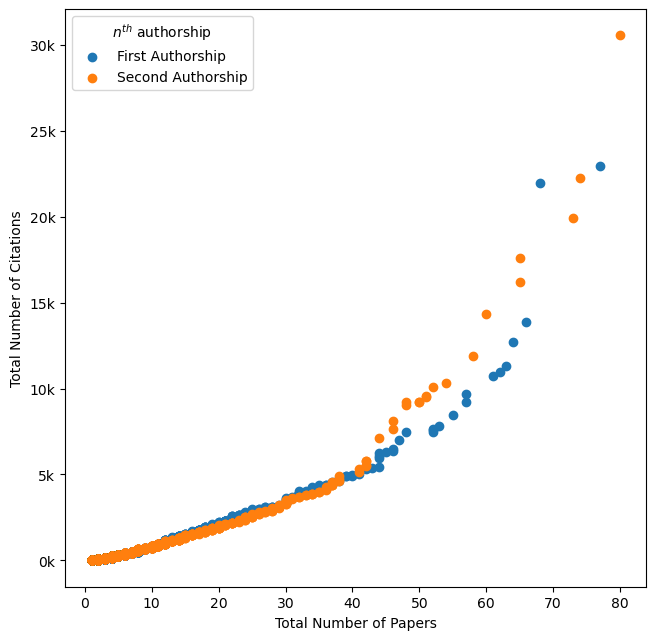

In [76]:
plt.figure(figsize=(7.5, 7.5))
plt.scatter(first_df1['Cites'].values, first_df['Cites'].values, label = 'First Authorship')
plt.scatter(sec_df1['Cites'].values, sec_df['Cites'].values, label = 'Second Authorship')

y_ticks = np.arange(0, 35000, 5000)
y_label = ['{}k'.format(int(y/1000)) for y in y_ticks]

plt.yticks(labels = y_label, ticks = y_ticks)
plt.ylabel('Total Number of Citations')
plt.xlabel('Total Number of Papers')
plt.legend(title = r'$n^{th}$ authorship')

#plt.title('The Number of Papers a Researcher has published as an $n^{th}$ author\n vs \nThe Number of Citations a Researcher has received as an $n^{th}$ author\n')
plt.savefig('2023-03-02 Cleaning DataSet V2.2.1.png', dpi = 100, transparent = True)

In [77]:
sns.lmplot(x = sec_df1['Cites'].values, y = sec_df['Cites'].values)

TypeError: Missing required keyword argument `data`.

In [78]:
df2_2['Source'].value_counts()

journal of physical chemistry c                  804
advanced materials                               723
applied physics letters                          667
acs energy letters                               575
acs applied materials &interfaces                558
                                                ... 
nonlinear optical effects in organic polymers      1
vakuum in forschung und praxis                     1
physchem                                           1
journal of applied research and technology         1
journal of the indian botanical society            1
Name: Source, Length: 1987, dtype: int64